In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
s_0 = 100 
mu = 0.10
sigma = 0.20
T = 1
N = 252 * T
dt = T / N
num_paths = 1000
Z = np.random.standard_normal((num_paths, N))

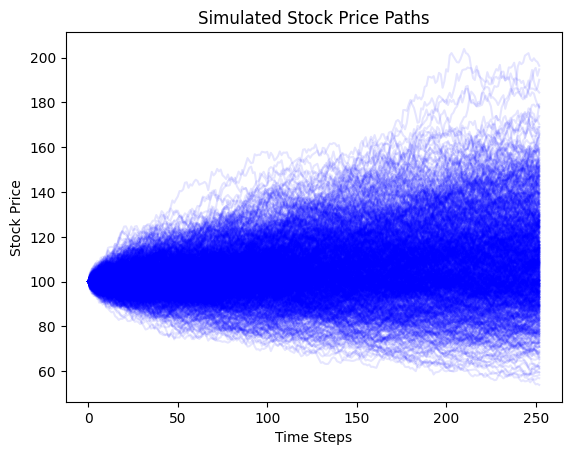

In [9]:
prices = np.zeros ((num_paths, N+1))
prices[:, 0] = s_0         
for t in range(1, N+1):
            prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

plt.plot(prices.T, color='blue', alpha=0.1)
plt.title('Simulated Stock Price Paths')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.show()

## Observations and some notes
This GBM simulator started as a single path on Excel before being scaled to 1000 paths in Python. Through experimentation with the parameters, the most important early insight was that **sigma dominates mu** in shaping the simulation. Higher mu shifts the cone upward: a modest directional effect. Higher sigma however drives the spread of outcomes explosively, capturing how volatility governs uncertainty far more than drift does. The scenario grid below makes this contrast visible across 16 parameter combinations.

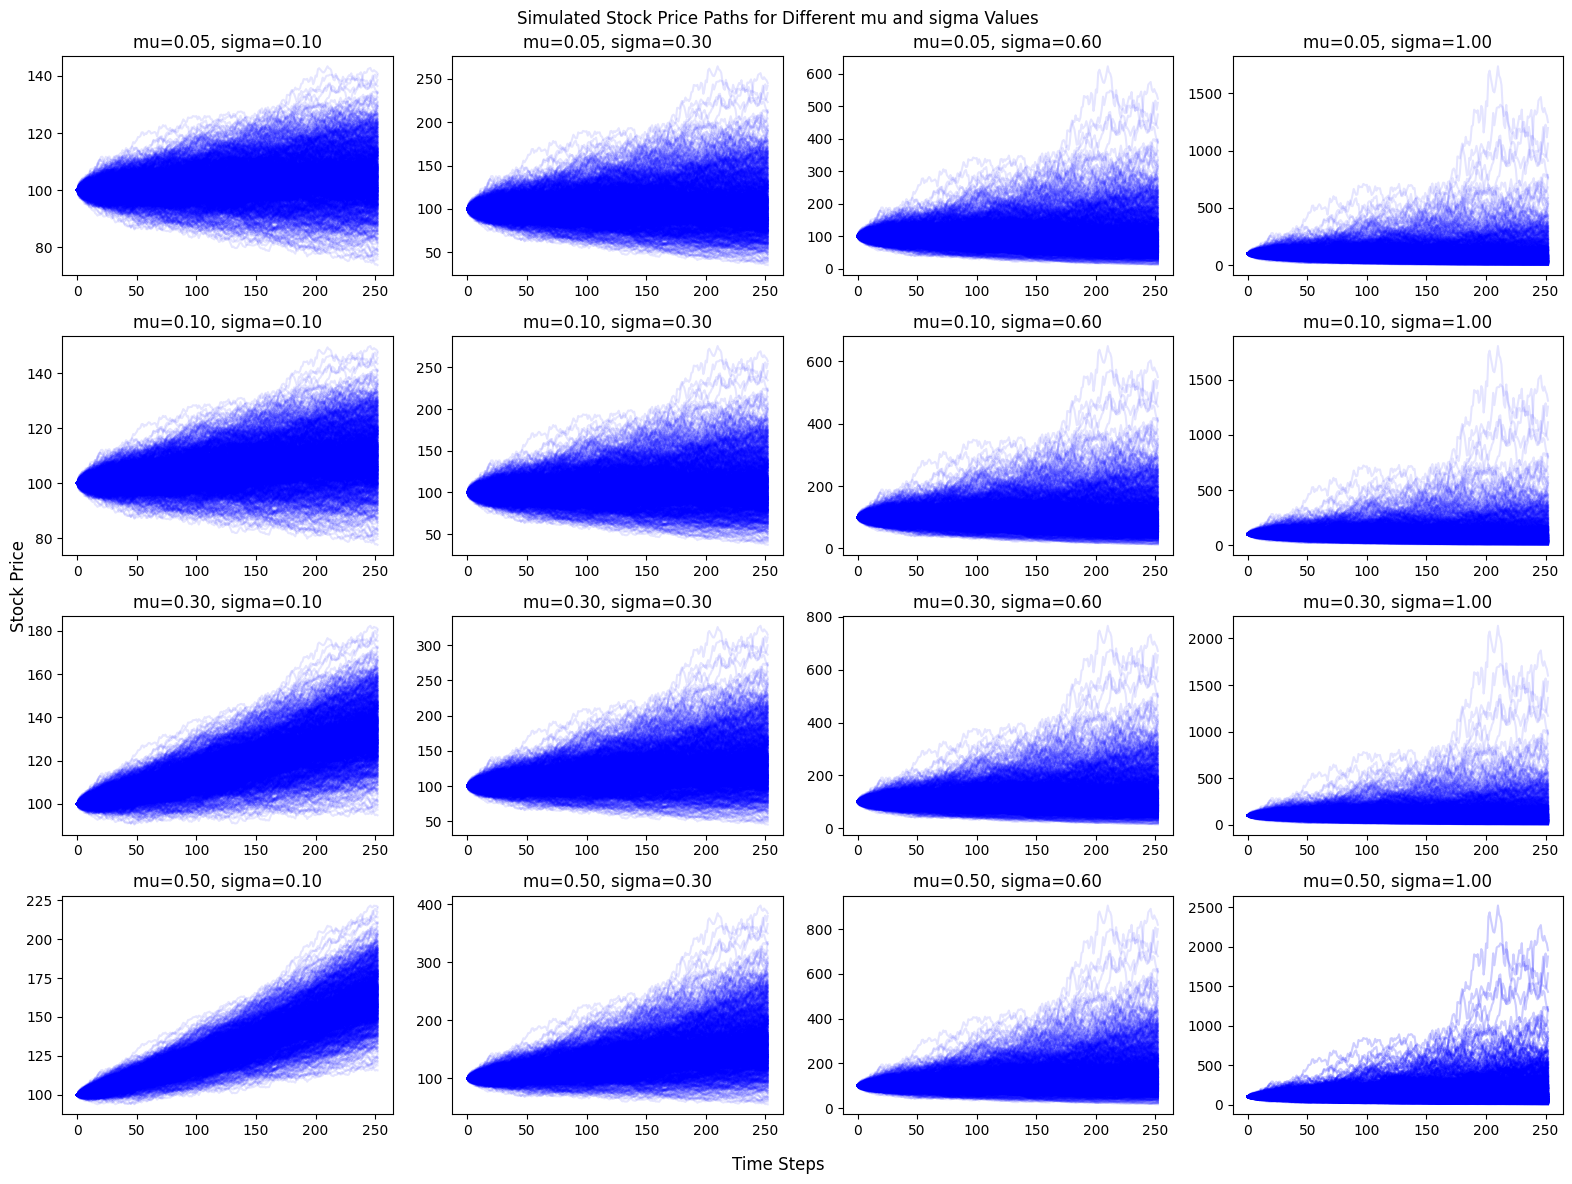

In [ ]:
mu_values = [0.05, 0.10, 0.30, 0.50]
sigma_values = [0.10, 0.30, 0.60, 1.00]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, mu in enumerate(mu_values):
    for j, sigma in enumerate(sigma_values):
        #  Building price paths
        prices = np.zeros ((num_paths, N+1))
        prices[:, 0] = s_0 
        for t in range(1, N+1):
            prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])
        # Plotting paths
        axes[i, j].plot(prices.T, alpha=0.1, color='blue')
        axes[i,j].set_title(f'mu={mu:.2f}, sigma={sigma:.2f}')

plt.suptitle('Simulated Stock Price Paths for Different mu and sigma Values')
fig.supxlabel('Time Steps')
fig.supylabel('Stock Price')
plt.tight_layout()
plt.show()

## Key Insight
As seen here, the higher mu values shift the cone upwards, and while it does affect the price, the sigma values dominate the shape of the graph as it "erases" this upward shift and instead shows how wildly prices can go up or down. This is most visible along the diagonal of the grid — low sigma plots retain the mu effect clearly, but as sigma increases, the drift becomes increasingly irrelevant. At sigma=1.00, the difference between mu=0.05 and mu=0.50 is virtually indistinguishable — volatility has completely swallowed the drift signal.

This has a direct implication in options trading — traders obsess over volatility (sigma) far more than drift (mu) because in the short term, sigma is what actually determines your outcome.

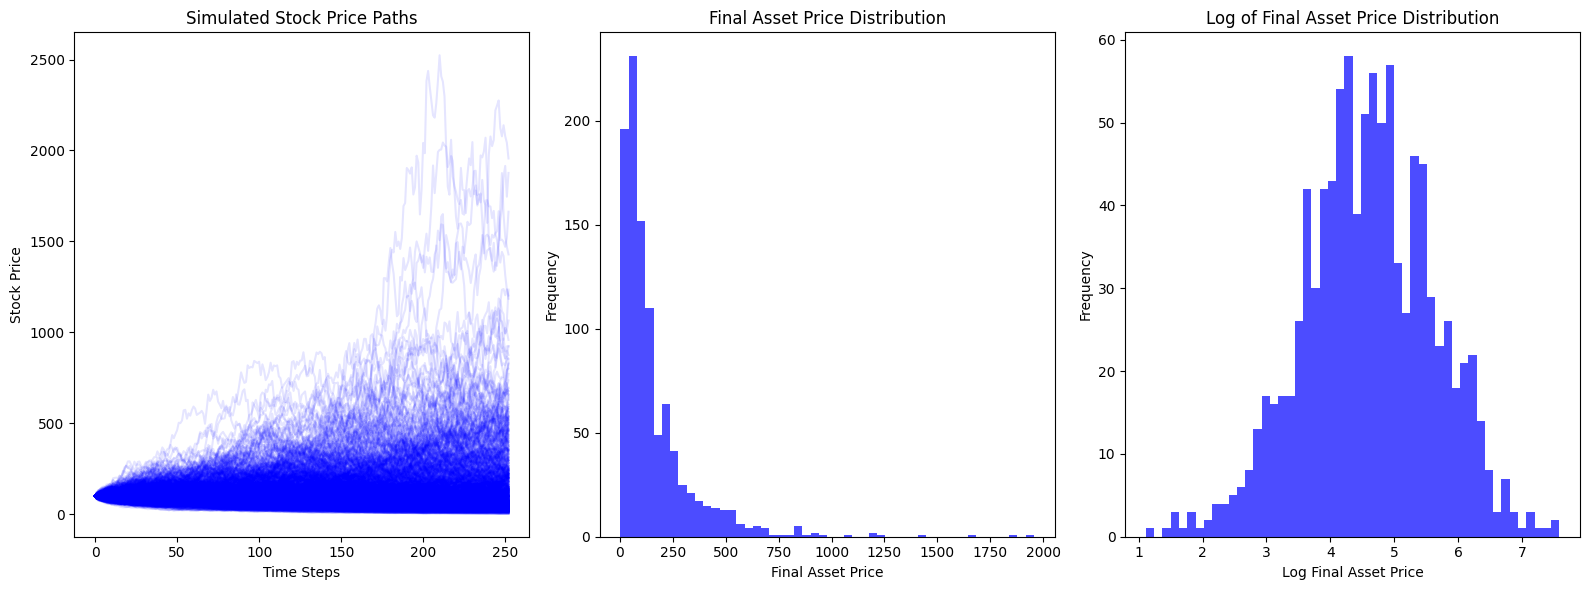

In [ ]:
# Reset to original parameters
mu, sigma = 0.10, 0.60
# Expanding time horizon to 2 years
T = 2
N = 252 * T
dt = T / N
prices = np.zeros((num_paths, N+1))
prices[:, 0] = s_0
for t in range(1, N+1):
    prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

# Getting final asset price for the 1000 paths
final_prices = prices[:, -1]
log_final_prices = np.log(final_prices)

# Plotting paths & final prices
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].plot(prices.T, color='blue', alpha=0.1)
ax[0].set_title('Simulated Stock Price Paths')
ax[0].set_xlabel('Time Steps')
ax[0].set_ylabel('Stock Price')

ax[1].hist(final_prices, bins=50, color='blue', alpha=0.7)
ax[1].set_title('Final Asset Price Distribution')
ax[1].set_xlabel('Final Asset Price')
ax[1].set_ylabel('Frequency')

ax[2].hist(log_final_prices, bins=50, color='blue', alpha=0.7)
ax[2].set_title('Log of Final Asset Price Distribution')
ax[2].set_xlabel('Log Final Asset Price')
ax[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Lognormal Price Distribution
The histogram of final asset prices shows a right skew, with prices that are always positive with a long tail to the upside. Taking the log of those final prices recovers a normal distribution, confirming that GBM's core assumption holds: log returns are normally distributed even though prices are not. This is why quant finance works with log returns rather than raw prices — the math is cleaner and the model stays consistent.

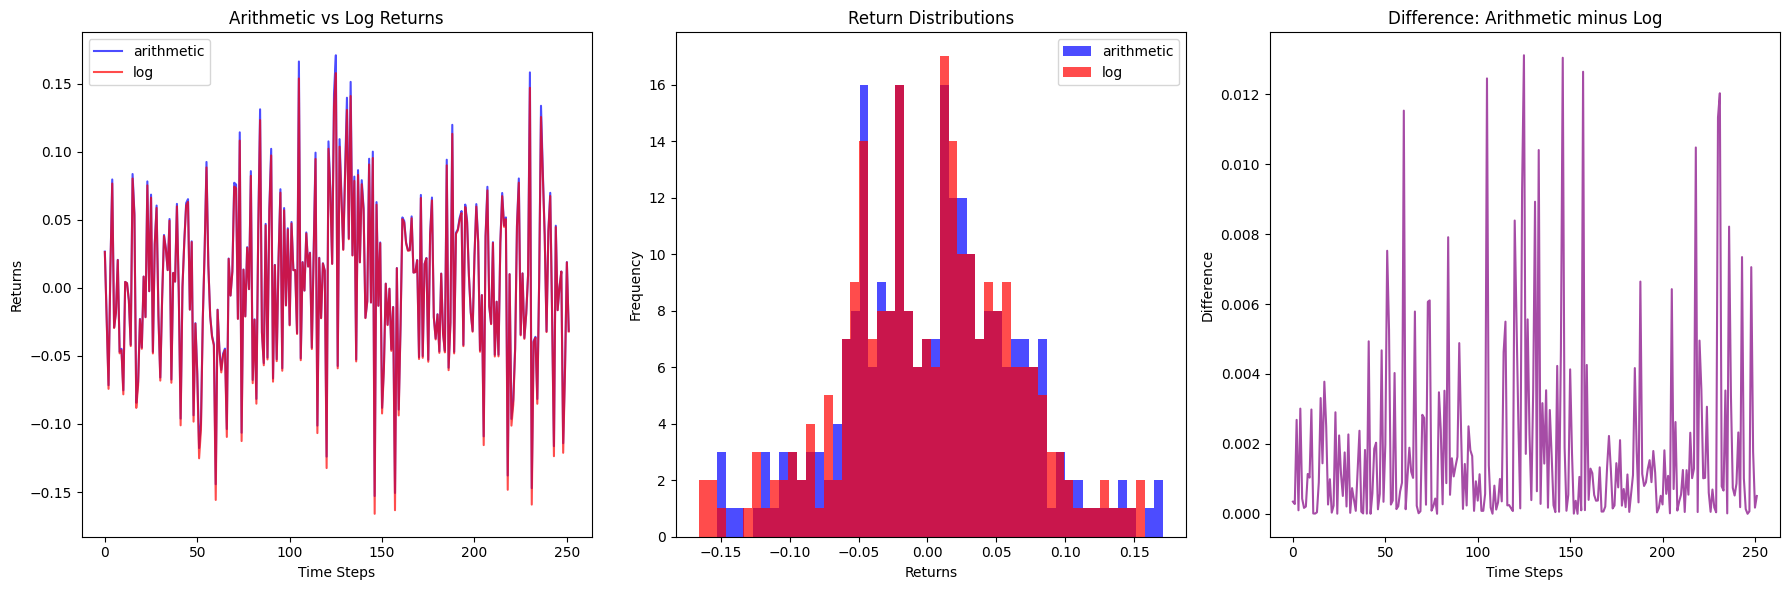

In [ ]:
# Computing arithmetic returns of a singular path
arithmetic_returns = (prices[0, 1:] - prices[0, :-1]) / prices[0, :-1]

# Computing log returns of a singular path
log_returns = np.log(prices[0, 1:] / prices[0, :-1])

# Plotting arithmetic returns & log returns, difference between arithmetic and log returns, 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Both returns overlaid
axes[0].plot(arithmetic_returns, color='blue', alpha=0.7, label='arithmetic')
axes[0].plot(log_returns, color='red', alpha=0.7, label='log')
axes[0].set_title('Arithmetic vs Log Returns')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Returns')
axes[0].legend()

# Plot 2 — Distributions
axes[1].hist(arithmetic_returns, bins=50, color='blue', alpha=0.7, label='arithmetic')
axes[1].hist(log_returns, bins=50, color='red', alpha=0.7, label='log')
axes[1].set_title('Return Distributions')
axes[1].set_xlabel('Returns')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3 — Difference
axes[2].plot(arithmetic_returns - log_returns, color='purple', alpha=0.7)
axes[2].set_title('Difference: Arithmetic minus Log')
axes[2].set_xlabel('Time Steps')
axes[2].set_ylabel('Difference')

plt.tight_layout()
plt.show()

## Difference between Artithmetic and Log Returns
Initially they do not look much different especially in the first graph, however it can be seen that there is a difference between these two, wherein arithmetic returns will show you you might have broken even with 50% growth then 50% loss, for example. But logarithmic returns will show that you actually lost 25%, which shows the compunding nature of log.

In the plots, the difference between the two is nearly invisible at the daily level — both overlap almost perfectly. However Plot 3 shows the difference is always positive, meaning arithmetic returns consistently overstate performance compared to log returns, even if only slightly. The compounding error is silent day-to-day but accumulates over time.

## Takeaways for the Week
This week gave me a first glimpse into how quant finance models uncertainty. The key shift in thinking is that GBM doesn't predict where a price will end up — it models the range of possible outcomes and how likely each one is. Volatility (sigma) dominates that range far more than drift (mu), which already hints at why options traders obsess over volatility rather than direction. The lognormal/normal relationship also showed me why the math is built on log returns rather than raw prices — it keeps the model consistent and the prices always positive. These feel like small technical details now but I suspect they'll show up everywhere in the weeks ahead.